In [ ]:
import pandas as pd
import spacy
nlp = spacy.load('en_core_web_sm')
import time
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MSDA683/HW3/Reviews.csv')

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
print(df.keys())

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [ ]:
df.shape

(568454, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [ ]:
rating_df = pd.DataFrame(df, columns=['Score','Text'])
print(rating_df.shape)
rating_df.head()

(568454, 2)


,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


In [ ]:
print(rating_df.keys())

Index(['Score', 'Text'], dtype='object')


In [ ]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Score   568454 non-null  int64 
 1   Text    568454 non-null  object
dtypes: int64(1), object(1)
memory usage: 8.7+ MB


In [ ]:
rating_df.Score.value_counts()

,count
Score,
5,363122
4,80655
1,52268
3,42640
2,29769


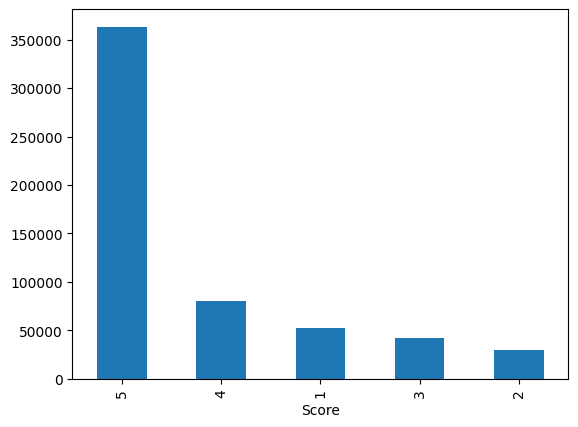

In [ ]:
rating_df.Score.value_counts().plot(kind='bar')
plt.savefig('/content/drive/MyDrive/MSDA683/QuantDistValues.jpg', bbox_inches='tight')

In [ ]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

rating_df['Text'] = rating_df['Text'].apply(lambda text: remove_urls(text))
rating_df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


In [ ]:
import string
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

rating_df['Text'] = rating_df['Text'].apply(lambda text: remove_punctuation(text))
rating_df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price There was a wide...


In [ ]:
fiveStardf = rating_df[df['Score'] == 5]


In [ ]:
fiveStardf.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
4,5,Great taffy at a great price There was a wide...
6,5,This saltwater taffy had great flavors and was...
7,5,This taffy is so good It is very soft and che...
8,5,Right now Im mostly just sprouting this so my ...


In [ ]:
fiveStarSamp = fiveStardf.sample(n=50000)
fiveStarSamp.shape

(50000, 2)

In [ ]:
start_time = time.perf_counter()
FiveStarAdj = []
FiveStarProds = []
for index, row in fiveStarSamp.iterrows():
  doc = nlp(row['Text'])
  for ent in doc.ents:
    if ent.label_ == 'PRODUCT':
      FiveStarProds.append(str(ent).lower().capitalize())
  for token in doc:
    if token.pos_ == 'ADJ':
      FiveStarAdj.append(str(token).capitalize())
end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(f"Found {len(FiveStarProds)} brands mentioned in {len(fiveStarSamp)} reviews" )

Elapsed time: 1155.16071548 seconds
Found 1960 brands mentioned in 50000 reviews


In [ ]:
 sorted_Prodlist = sorted(FiveStarProds, key=str)
 top_Prodlist = pd.DataFrame(Counter(sorted_Prodlist).most_common(20), columns=['Product','Count'])
 print(top_Prodlist)

          Product  Count
0       Subscribe     93
1        Gatorade     69
2       Starbucks     67
3     Recommended     35
4   Crystal light     25
5          Stashs     22
6              Ca     21
7          Family     20
8           Gooey     20
9        Larabars     20
10           Made     20
11           Pero     20
12      Diet coke     19
13        Splenda     14
14        Vanilla     14
15        Classic     13
16   Butterfinger     12
17     Convenient     12
18        Healthy     12
19            Mio     12


In [ ]:
final_list = top_Prodlist

In [ ]:
final_list = final_list.drop(index=14)

In [ ]:
print(final_list)

          Product  Count
1        Gatorade     69
2       Starbucks     67
4   Crystal light     25
5          Stashs     22
8           Gooey     20
9        Larabars     20
10           Made     20
11           Pero     20
12      Diet coke     19
13        Splenda     14
16   Butterfinger     12
19            Mio     12


In [ ]:
plot = final_list.plot.barh(x='Product', y='Count',
                            title='Common Products Mentioned in 5-Star Reviews').invert_yaxis()
plt.savefig('/content/drive/MyDrive/MSDA683/5starBrands.jpg', bbox_inches='tight')

NameError: name 'final_list' is not defined

In [ ]:
sorted_Adjlist = sorted(FiveStarAdj, key=str)
top_Adjlist = pd.DataFrame(Counter(sorted_Adjlist).most_common(20), columns=['Adjective','Count'])
print(top_Adjlist)

    Adjective  Count
0       Great  16480
1        Good  15162
2       Other   8737
3        Best   6633
4      Little   6336
5        More   6024
6      Better   3995
7   Delicious   3895
8       Sweet   3825
9        Many   3753
10   Favorite   3729
11    Perfect   3319
12    Healthy   3314
13       Free   3217
14       Nice   3203
15        Hot   3139
16        Few   3072
17      First   2757
18  Different   2706
19      Happy   2703


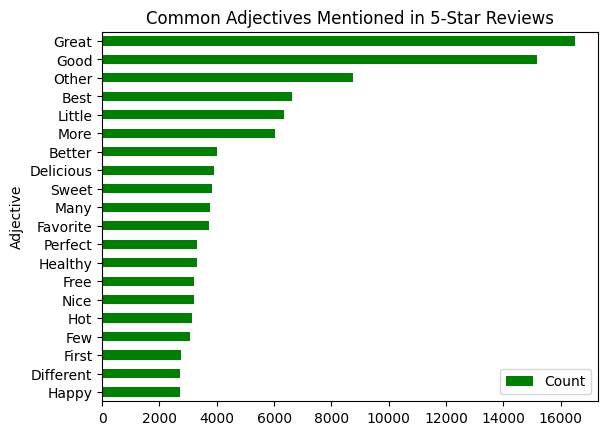

In [ ]:
plot = top_Adjlist.plot.barh(x='Adjective', y='Count', color = 'green',
                            title='Common Adjectives Mentioned in 5-Star Reviews').invert_yaxis()
plt.savefig('/content/drive/MyDrive/MSDA683/5starADJ.jpg', bbox_inches='tight')

In [ ]:
start_time = time.perf_counter()
FiveStarAdjOne = []
for index, row in fiveStarSamp.iterrows():
  doc = nlp(row['Text'])
  for ent in doc.ents:
    if ent.label_ == 'PRODUCT' and str(ent).lower() == "diet coke":
      for token in doc:
        if token.pos_ == 'ADJ':
          FiveStarAdjOne.append(str(token).capitalize())
end_time = time.perf_counter()
print(f"Elapsed time: {end_time - start_time} seconds")
print(FiveStarAdjOne)

Elapsed time: 1076.5888596980003 seconds
['333br', 'Same', 'Public', 'Bad', 'Hardbr', 'Other', 'Diet', 'Least', 'Favorite', 'Enough', 'Darn', 'Better', 'Thanbr', 'Impressed', 'Best', 'Favorite', 'Common', 'Great', 'Ok', 'Nice', 'Free', 'Less', 'Traditional', 'Soft', 'Available', 'First', 'Diet', 'Soft', 'Above', 'Available', 'Nondiet', 'Soft', 'Other', 'Subjective', 'Above', 'True', 'Disappointing', 'Balanced', 'Same', 'Regular', 'Regular', 'Last', 'True', 'True', 'Disappointing', 'Balanced', 'Same', 'Regular', 'Regular', 'Last', 'True', 'True', 'Disappointing', 'Balanced', 'Same', 'Regular', 'Regular', 'Last', 'True', 'True', 'Disappointing', 'Balanced', 'Same', 'Regular', 'Regular', 'Last', 'True', 'True', 'Disappointing', 'Balanced', 'Same', 'Regular', 'Regular', 'Last', 'True', 'Favorite', 'Extreme', 'Vocal', 'Carbonationbr', 'Many', 'Good', 'Much', 'Natural', 'Available', 'Other', 'High', 'Most', 'Concerned', 'Natural', 'Favorite', 'Close', 'Familiar', 'Proud', 'Pure', 'Pure', 'Sp

In [ ]:
sorted_AdjlistOne = sorted(FiveStarAdjOne, key=str)
top_AdjlistOne = pd.DataFrame(Counter(sorted_AdjlistOne).most_common(20), columns=['Adjective','Count'])
print(top_AdjlistOne)

        Adjective  Count
0            True     11
1         Regular     10
2             Bad      7
3        Favorite      7
4            Good      7
5           Other      7
6           Great      6
7            Pure      6
8            Same      6
9       Available      5
10       Balanced      5
11  Disappointing      5
12           Last      5
13           Many      4
14        Natural      4
15           Free      3
16           High      3
17           Soft      3
18          Sweet      3
19           Able      2


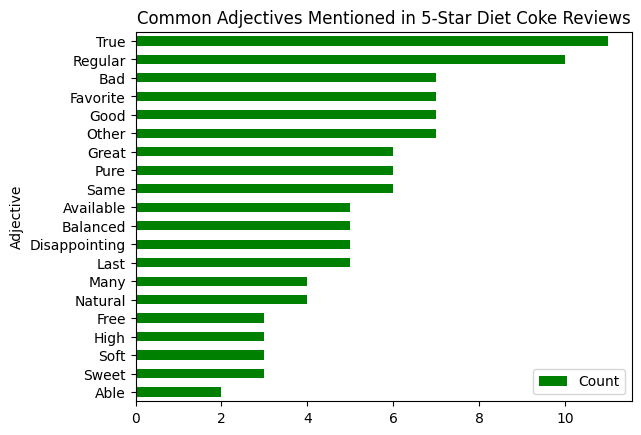

In [ ]:
plot = top_AdjlistOne.plot.barh(x='Adjective', y='Count', color = 'green',
                            title='Common Adjectives Mentioned in 5-Star Diet Coke Reviews').invert_yaxis()
plt.savefig('/content/drive/MyDrive/MSDA683/dietcoke5starADJ.jpg', bbox_inches='tight')